# Wave equations: d’Alembert propagation

For $u_{tt}=u_{xx}$ on the full line with initial displacement $\sin x$ and zero velocity, d’Alembert’s formula exposes the two traveling-wave components.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. DerivationFor wave speed $c=1$,$$u(x,t)=\frac{f(x-t)+f(x+t)}2+\frac12\int_{x-t}^{x+t}g(s)\,ds.$$With $f(x)=\sin x$ and $g(x)=0$,$$u(x,t)=\frac{\sin(x-t)+\sin(x+t)}2=\sin x\cos t.$$

In [3]:
x, t = sp.symbols("x t", real=True)
u = sp.Function("u")
eq = sp.Eq(sp.diff(u(x,t),t,2), sp.diff(u(x,t),x,2))
ics = {"initial_displacement":lambda z:sp.sin(z), "initial_velocity":lambda z:0}
problem = pds.build_pde_problem(eq, u(x,t), (x,t), ics=ics)
recognition, plan = show_plan(problem)

Recognition: (PDERecognitionRecord(family='wave_like', recognized=True, solver_hint='wave_dalembert', tags=('dAlembert', 'separation_of_variables'), metadata={}),)Top plan steps:  wave_dalembert                             score=97  constant_coefficient_inverse_operator      score=92  structured_transform                       score=77  symmetry_reduction                         score=60  post_reduction_auto                        score=48  classification_only                        score=20

PDESolutionRecord dAlembert_wave_ivp

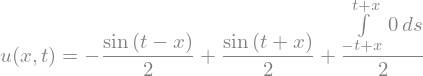

Verification: {'verified': True, 'status': 'verified', 'pde_verified': True, 'initial_verified': True, 'boundary_verified': None, 'pde_residual': 0, 'initial_residuals': (0, 0), 'boundary_residuals': (), 'mode': 'symbolic', 'message': ''}

In [4]:
result = pds.pdesolve(eq, u(x,t), (x,t), ics=ics, method="auto")
print(type(result).__name__, result.method)
display(result.solution)
print("Verification:", result.verification)

In [5]:
sol = sp.simplify(rhs_of(result.solution).doit())
print("Simplified:"); display(sp.trigsimp(sol))
assert sp.simplify(sp.diff(sol,t,2)-sp.diff(sol,x,2)) == 0
assert sp.simplify(sol.subs(t,0)-sp.sin(x)) == 0
assert sp.simplify(sp.diff(sol,t).subs(t,0)) == 0

Simplified:

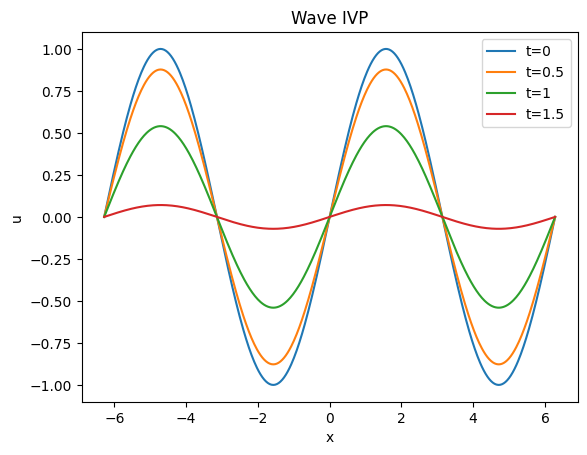

In [6]:
xx = np.linspace(-2*np.pi, 2*np.pi, 500)
fig, ax = plt.subplots()
for tv in [0.0, 0.5, 1.0, 1.5]:
    ax.plot(xx, np.sin(xx)*np.cos(tv), label=f"t={tv:g}")
ax.set_xlabel("x"); ax.set_ylabel("u"); ax.set_title("Wave IVP")
ax.legend(); plt.show()

## 3. Variation and exercisesUse nonzero initial velocity below. Then: (1) derive the extra integral term; (2) compare full-line d’Alembert with finite-interval sine-series routing; (3) identify left- and right-moving components.

dAlembert_wave_ivp

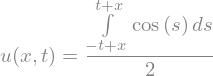

In [7]:
ics2 = {"initial_displacement":lambda z:0, "initial_velocity":lambda z:sp.cos(z)}
r2 = pds.pdesolve(eq, u(x,t), (x,t), ics=ics2, method="auto")
print(r2.method); display(r2.solution)